/tmp/ipykernel_55/2265591936.py:192: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler     = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))


Resumed from epoch 2, best_acc=0.0000


/tmp/ipykernel_55/2265591936.py:217: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):
/tmp/ipykernel_55/2265591936.py:248: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):
/tmp/ipykernel_55/2265591936.py:266: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):


Epoch   3 | Train: 0.8100 | Test (TTA): 0.6975
  ✓ New best: 0.6975
Epoch   4 | Train: 0.8418 | Test (TTA): 0.6744
Epoch   5 | Train: 0.8579 | Test (TTA): 0.8006
  ✓ New best: 0.8006
Epoch   6 | Train: 0.8820 | Test (TTA): 0.7275
Epoch   7 | Train: 0.8930 | Test (TTA): 0.8688
  ✓ New best: 0.8688
Epoch   8 | Train: 0.9064 | Test (TTA): 0.8925
  ✓ New best: 0.8925
Epoch   9 | Train: 0.9127 | Test (TTA): 0.9119
  ✓ New best: 0.9119
Epoch  10 | Train: 0.9186 | Test (TTA): 0.8650
Epoch  11 | Train: 0.9282 | Test (TTA): 0.8906
Epoch  12 | Train: 0.9366 | Test (TTA): 0.9125
  ✓ New best: 0.9125
Epoch  13 | Train: 0.9387 | Test (TTA): 0.9219
  ✓ New best: 0.9219
Epoch  14 | Train: 0.9430 | Test (TTA): 0.9163
Epoch  15 | Train: 0.9525 | Test (TTA): 0.9113
Epoch  16 | Train: 0.9518 | Test (TTA): 0.9231
  ✓ New best: 0.9231
Epoch  17 | Train: 0.9582 | Test (TTA): 0.9100
Epoch  18 | Train: 0.9596 | Test (TTA): 0.9213
Epoch  19 | Train: 0.9596 | Test (TTA): 0.9087
Epoch  20 | Train: 0.9618 | Test 

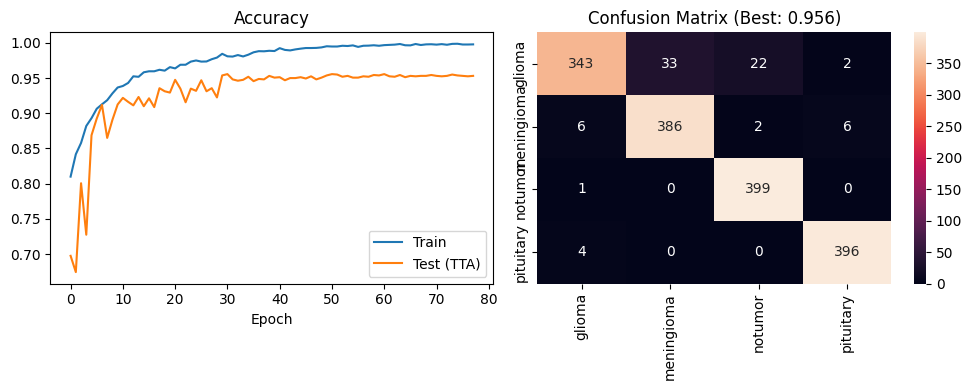

In [ ]:
!pip install snntorch -q

import os
import torch
import torch.nn as nn
import zipfile
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from collections import Counter
import snntorch as snn
from snntorch import surrogate
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np


zip_path = "brain_tumor_dataset.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("data")

base_dir = "data"
train_dir = os.path.join(base_dir, "Training")
test_dir = os.path.join(base_dir, "Testing")

classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

train_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, translate=(0.08,0.08)),
    transforms.ColorJitter(0.15,0.15),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x + 0.02*torch.randn_like(x)),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_dataset = ImageFolder(train_dir, transform=train_transform)
test_dataset = ImageFolder(test_dir, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# Class weights
train_labels = train_dataset.targets
class_counts = Counter(train_labels)
weights = torch.tensor([1.0/class_counts[i] for i in range(len(classes))]).float()

device = "cuda" if torch.cuda.is_available() else "cpu"
weights = weights.to(device)

criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.05)

# ================= MODEL =================
beta = 0.5
spike_grad = surrogate.fast_sigmoid()

class SEBlock(nn.Module):
    def __init__(self, ch, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(ch, ch//reduction),
            nn.ReLU(),
            nn.Linear(ch//reduction, ch),
            nn.Sigmoid()
        )
    def forward(self, x):
        w = self.fc(x).view(x.size(0), x.size(1), 1, 1)
        return x * w

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch)
        )
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.se = SEBlock(out_ch)

    def forward(self, x):
        out = self.conv(x)
        out += self.shortcut(x)
        return self.se(torch.relu(out))

class BigSNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = ResBlock(3, 64)
        self.layer2 = ResBlock(64, 128)
        self.layer3 = ResBlock(128, 256)
        self.layer4 = ResBlock(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.lif_mid1 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.lif_mid2 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)

        self.fc1 = nn.Linear(512*8*8, 1024)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(1024, 4)

    def forward(self, x, T=4):
        mem_mid1 = self.lif_mid1.init_leaky()
        mem_mid2 = self.lif_mid2.init_leaky()
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        outputs = []
        x_seq = x.unsqueeze(0).repeat(T,1,1,1,1)

        for step in range(T):
            x_t = x_seq[step]

            x1 = self.pool(self.layer1(x_t))
            spk_mid1, mem_mid1 = self.lif_mid1(x1, mem_mid1)

            x2 = self.pool(self.layer2(spk_mid1))
            spk_mid2, mem_mid2 = self.lif_mid2(x2, mem_mid2)

            x3 = self.pool(self.layer3(spk_mid2))
            x4 = self.pool(self.layer4(x3))

            spk1, mem1 = self.lif1(x4, mem1)

            flat = spk1.view(spk1.size(0), -1)
            flat = self.dropout(flat)

            fc = self.fc1(flat)
            spk2, mem2 = self.lif2(fc, mem2)

            out = self.fc2(spk2)
            outputs.append(out)

        return torch.stack(outputs).mean(0)

model = BigSNN().to(device)

# ================= OPTIMIZER =================
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=60)

#  MIXED PRECISION
scaler = torch.cuda.amp.GradScaler(enabled=(device=="cuda"))

# ================= CHECKPOINT =================
start_epoch = 0
best_acc = 0
patience = 10
counter = 0

if os.path.exists("checkpoint.pth"):
    print("Loading checkpoint...")
    checkpoint = torch.load("checkpoint.pth", map_location=device)

    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])
    scheduler.load_state_dict(checkpoint['scheduler_state'])

    start_epoch = checkpoint['epoch'] + 1
    best_acc = checkpoint['best_acc']

    print(f"Resuming from epoch {start_epoch}")

# ================= TRAIN =================
epochs = 80

train_acc_list, test_acc_list = [], []

for epoch in range(start_epoch, epochs):
    model.train()
    correct, total, train_loss = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=(device=="cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss += 1e-4 * torch.mean(outputs**2)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        _, pred = outputs.max(1)
        correct += pred.eq(labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    # ================= TEST =================
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            with torch.cuda.amp.autocast(enabled=(device=="cuda")):
                outputs = model(images)

            _, pred = outputs.max(1)
            correct += pred.eq(labels).sum().item()
            total += labels.size(0)

    test_acc = correct / total
    scheduler.step()

    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)

    print(f"{epoch+1} | Train: {train_acc:.4f} | Test: {test_acc:.4f}")

    #  SAVE CHECKPOINT EVERY EPOCH
    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(),
        'best_acc': best_acc
    }, "checkpoint.pth")

    #  BEST MODEL
    if test_acc > best_acc:
        best_acc = test_acc
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
        print("Best model saved!")
    else:
        counter += 1

    #  EARLY STOPPING
    if counter >= patience:
        print("Early stopping triggered")
        break

print("Best Test Accuracy:", best_acc)

# ================= PLOTS =================
plt.plot(train_acc_list, label="Train")
plt.plot(test_acc_list, label="Test")
plt.legend()
plt.title("Accuracy")
plt.show()

# ================= CONFUSION =================
all_preds, all_labels = [], []

model.load_state_dict(torch.load("best_model.pth"))
model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, pred = outputs.max(1)

        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classes,
            yticklabels=classes)
plt.title(f"Confusion Matrix (Best: {best_acc:.3f})")
plt.show()